# Starlit Canopy — Guest Intent Classification
Classifying hotel reviews into 4 experience pillars: **Solitude/Peace**, **Outdoor Adventure**, **Luxury/Comfort**, **Social/Family**

### 1. Setup & Imports

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))
sns.set_theme(style='whitegrid')

### 2. Load Data

In [29]:
df = pd.read_csv('tripadvisor_hotel_reviews.csv')
print(df.shape)
df.head()

(20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


### 3. Text Preprocessing

In [30]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]','', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return' '.join(tokens)

df['clean_review']= df['Review'].apply(clean_text)
df[['Review','clean_review']].head(3)
                  

,Review,clean_review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice rooms experience hotel monaco seattle goo...


### 4. Keyword-based labelling
Since the dataset has no pillar labels, we assign them using keywords, Reviews matching multiple pillars take the first match in priority order.

In [31]:
pillar_keywords = {
    'Solitude/Peace':      ['quiet', 'peaceful', 'serene', 'secluded', 'tranquil', 'calm', 'escape', 'retreat', 'silent', 'isolated'],
    'Outdoor Adventure':   ['hiking', 'trail', 'safari', 'kayak', 'adventure', 'wildlife', 'nature', 'explore', 'outdoor', 'trek'],
    'Luxury/Comfort':      ['luxury', 'spa', 'comfortable', 'elegant', 'amenities', 'premium', 'plush', 'exquisite', 'indulge', 'upscale'],
    'Social/Family':       ['family', 'kids', 'children', 'friends', 'group', 'together', 'fun', 'party', 'celebrate', 'reunion']
}

def assign_label(text):
    scores = {}

    for pillar, keywords in pillar_keywords.items():
        scores[pillar]= sum(kw in text for kw in keywords)

    best_pillar = max(scores, key=scores.get)

    if scores[best_pillar] == 0:
        return None
    
    return best_pillar

df['label']= df['clean_review'].apply(assign_label)
df = df.dropna(subset=['label'])

print(f"Labelled reviews: {len(df)}")
df['label'].value_counts()

Labelled reviews: 13208


label
Luxury/Comfort       6437
Social/Family        3488
Solitude/Peace       2593
Outdoor Adventure     690
Name: count, dtype: int64

### 5. Train/ Test split and model

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], df['label'], test_size=0.2, random_state= 42, stratify=df['label']
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_test_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)


model = LogisticRegression(max_iter=1000, random_state= 42, class_weight='balanced')
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print(classification_report(y_test,y_pred))

                   precision    recall  f1-score   support

   Luxury/Comfort       0.88      0.80      0.84      1287
Outdoor Adventure       0.48      0.64      0.55       138
    Social/Family       0.76      0.86      0.81       698
   Solitude/Peace       0.82      0.78      0.80       519

         accuracy                           0.81      2642
        macro avg       0.74      0.77      0.75      2642
     weighted avg       0.82      0.81      0.81      2642



### 6. Confusion matrix

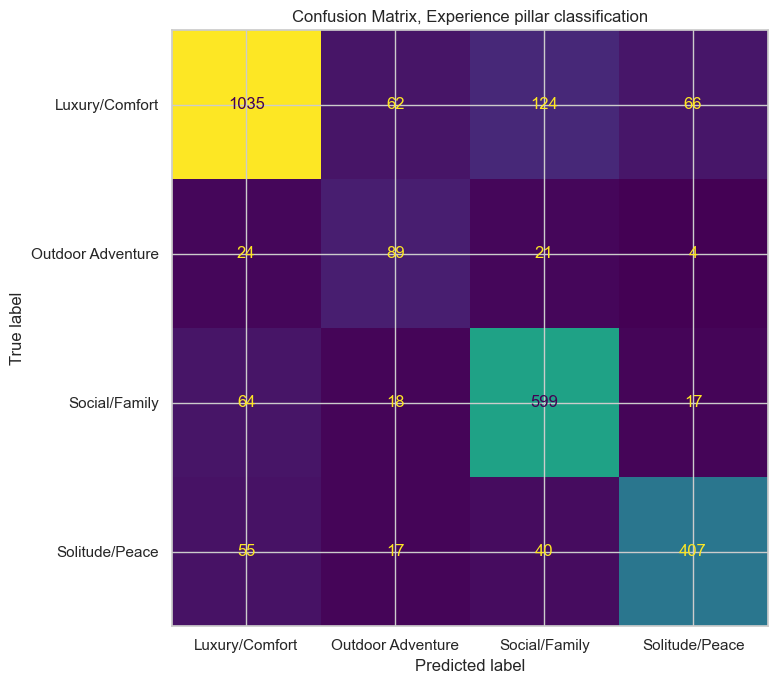

In [39]:
fig, ax = plt.subplots(figsize=(9,7))

labels = model.classes_

cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=labels)

disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix, Experience pillar classification')

plt.tight_layout()
plt.show()

### 7. Pillar Distribution

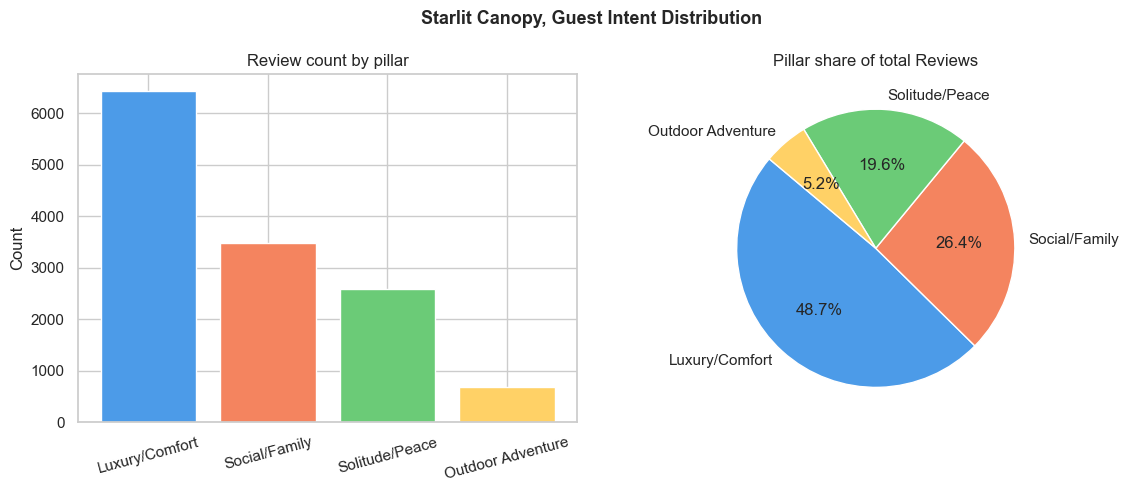

In [42]:
counts = df['label'].value_counts()
colors = ['#4C9BE8','#F4845F', '#6BCB77', '#FFD166']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Review count by pillar')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

#Pie chart
axes[1].pie(counts.values, labels= counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Pillar share of total Reviews')

plt.suptitle('Starlit Canopy, Guest Intent Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8 Top Keywords per pillar

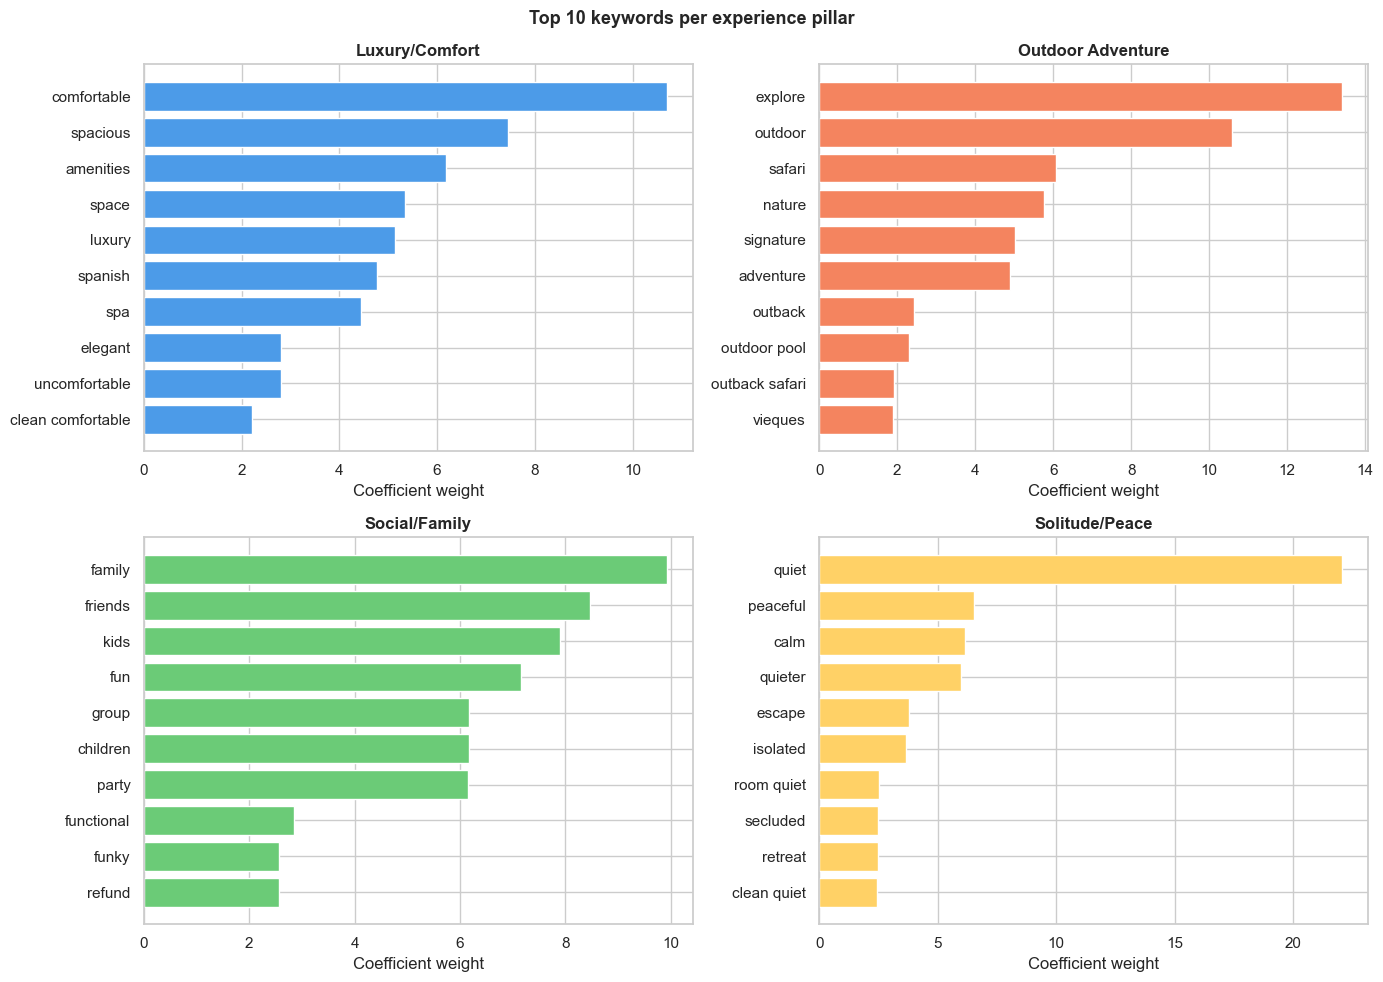

In [46]:
feature_names = tfidf.get_feature_names_out()
top_n = 10

fig, axes = plt.subplots(2,2, figsize=(14,10))
axes = axes.flatten()

for i, (cls, color) in enumerate(zip(model.classes_, colors)):
    coef = model.coef_[i]
    top_idx = np.argsort(coef)[-top_n:][::-1]
    top_words= [feature_names[j] for j in top_idx]
    top_scores = [coef[j] for j in top_idx]

    axes[i].barh(top_words[::-1], top_scores[::-1], color=color, edgecolor='white')
    axes[i].set_title(f'{cls}', fontweight='bold')
    axes[i].set_xlabel('Coefficient weight')


plt.suptitle('Top 10 keywords per experience pillar', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 9. keyword summary table

In [48]:
summary = {}
for i, cls in enumerate(model.classes_):
    coef = model.coef_[i]
    top_idx = np.argsort(coef)[-5:][::-1]
    summary[cls]= ', '.join([feature_names[j] for j in top_idx])

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Top 5 Keywords'])
summary_df.index.name = "Experience Pillar"
summary_df

,Top 5 Keywords
Experience Pillar,
Luxury/Comfort,"comfortable, spacious, amenities, space, luxury"
Outdoor Adventure,"explore, outdoor, safari, nature, signature"
Social/Family,"family, friends, kids, fun, group"
Solitude/Peace,"quiet, peaceful, calm, quieter, escape"


### 10. Quick Inference Test
Test the model on two smaple reviews matching different pillars.

In [50]:
samples =[
    "We loved the quite forest escape, completely secluded from the world"
    "The spa tent was absolutely luxurious with premium amentities throughout"
]

cleaned = [clean_text(s) for s in samples]
preds = model.predict(tfidf.transform(cleaned))

for review, pred in zip(samples, preds):
    print(f"Review : {review}")
    print(f"Pillar : {pred}\n")

Review : We loved the quite forest escape, completely secluded from the worldThe spa tent was absolutely luxurious with premium amentities throughout
Pillar : Solitude/Peace



## Summary

This notebook classifies TripAdvisor hote reviews into 4 experience pillars for Starlit Canopy: Solitude/peace, Outdoor, Aventure, Luxury/Comfort, and social/family

Reviews were labelled using keyword scoring (best match wins), vectorized with TF-IDF, and classified using Logistic Regression with balanced class weights.

What we found: 
- Luxury/Comfort dominates at 48.7% of reviews, guests are primarily booking for amenities and comfort
- Social/Family is secon at 26.4%, followed by Solitued/Peace at 19.6%
- Outdoor Adventure is underrespresented at just 5.2%, a potential untapped market

Model Performance (81% accuracy):
- Luxury and Social perform strongest (F1 0.84 , 0.81)
- solitude close behind at F1 0.80
- Outdoor Adventure at F1 0.55, lower due to limited training samples

Ad spend recommendation: prioritize luxury and family messaging where guest intent is strongest, wwhile testing adventure-focused creatives to explore teh undereserved 5,2% segment